# Part 2A — Data Segmentation: Otsu Brain Extraction
**Unit:** CIS143-6 Applications of AI  
**Technique:** Otsu Thresholding (Otsu, 1979) for tumour-region isolation  
> Run after `part1_baseline.ipynb`. Requires the dataset cached in `/content/brain_tumour_data` or Google Drive.

## 0. Setup

In [17]:
import os, random, shutil, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2
from PIL import Image

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.model_selection import train_test_split

warnings.filterwarnings('ignore')
tf.random.set_seed(42)
np.random.seed(42)
random.seed(42)

print('TensorFlow:', tf.__version__)
print('GPU:', tf.config.list_physical_devices('GPU'))

TensorFlow: 2.20.0-dev0+selfbuilt
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

DRIVE_DIR = Path('/content/drive/MyDrive/brain_tumour_mri')
DRIVE_DIR.mkdir(parents=True, exist_ok=True)

DATA_DIR = Path('/content/brain_tumour_data')
if not DATA_DIR.exists():
    drive_dataset = DRIVE_DIR / 'dataset'
    if drive_dataset.exists():
        shutil.copytree(drive_dataset, DATA_DIR)
        print('Dataset restored from Drive.')
    else:
        raise RuntimeError('Dataset not found. Run part1_baseline.ipynb first.')
else:
    print('Dataset already cached.')

TRAIN_DIR = DATA_DIR / 'Training'
CLASSES = ['glioma', 'meningioma', 'notumor', 'pituitary']
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

[local] drive.mount skipped — running outside Colab
Dataset already cached.


In [19]:
# Rebuild the same train/val/test split as Part 1 (same seed = same files)
records = []
for cls in CLASSES:
    for img_path in (TRAIN_DIR / cls).glob('*.jpg'):
        records.append({'filepath': str(img_path), 'label': cls})

df = pd.DataFrame(records).sample(frac=1, random_state=42).reset_index(drop=True)
train_df, temp_df = train_test_split(df, test_size=0.30, stratify=df['label'], random_state=42)
val_df, test_df   = train_test_split(temp_df, test_size=0.50, stratify=temp_df['label'], random_state=42)
print(f'Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}')

Train: 3920 | Val: 840 | Test: 840


## 2. Otsu Thresholding Implementation

In [ ]:
def otsu_segment(img_array):
    gray = cv2.cvtColor((img_array * 255).astype(np.uint8), cv2.COLOR_RGB2GRAY)

    _, mask = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)

    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if contours:
        largest = max(contours, key=cv2.contourArea)
        clean_mask = np.zeros_like(mask)
        cv2.drawContours(clean_mask, [largest], -1, 255, -1)
        mask = clean_mask

    mask_3ch = np.stack([mask / 255.0] * 3, axis=-1).astype(np.float32)
    return img_array * mask_3ch

print('Otsu segmentation function defined.')

Otsu segmentation function defined.


## 3. Visualisation — Original vs Mask vs Segmented

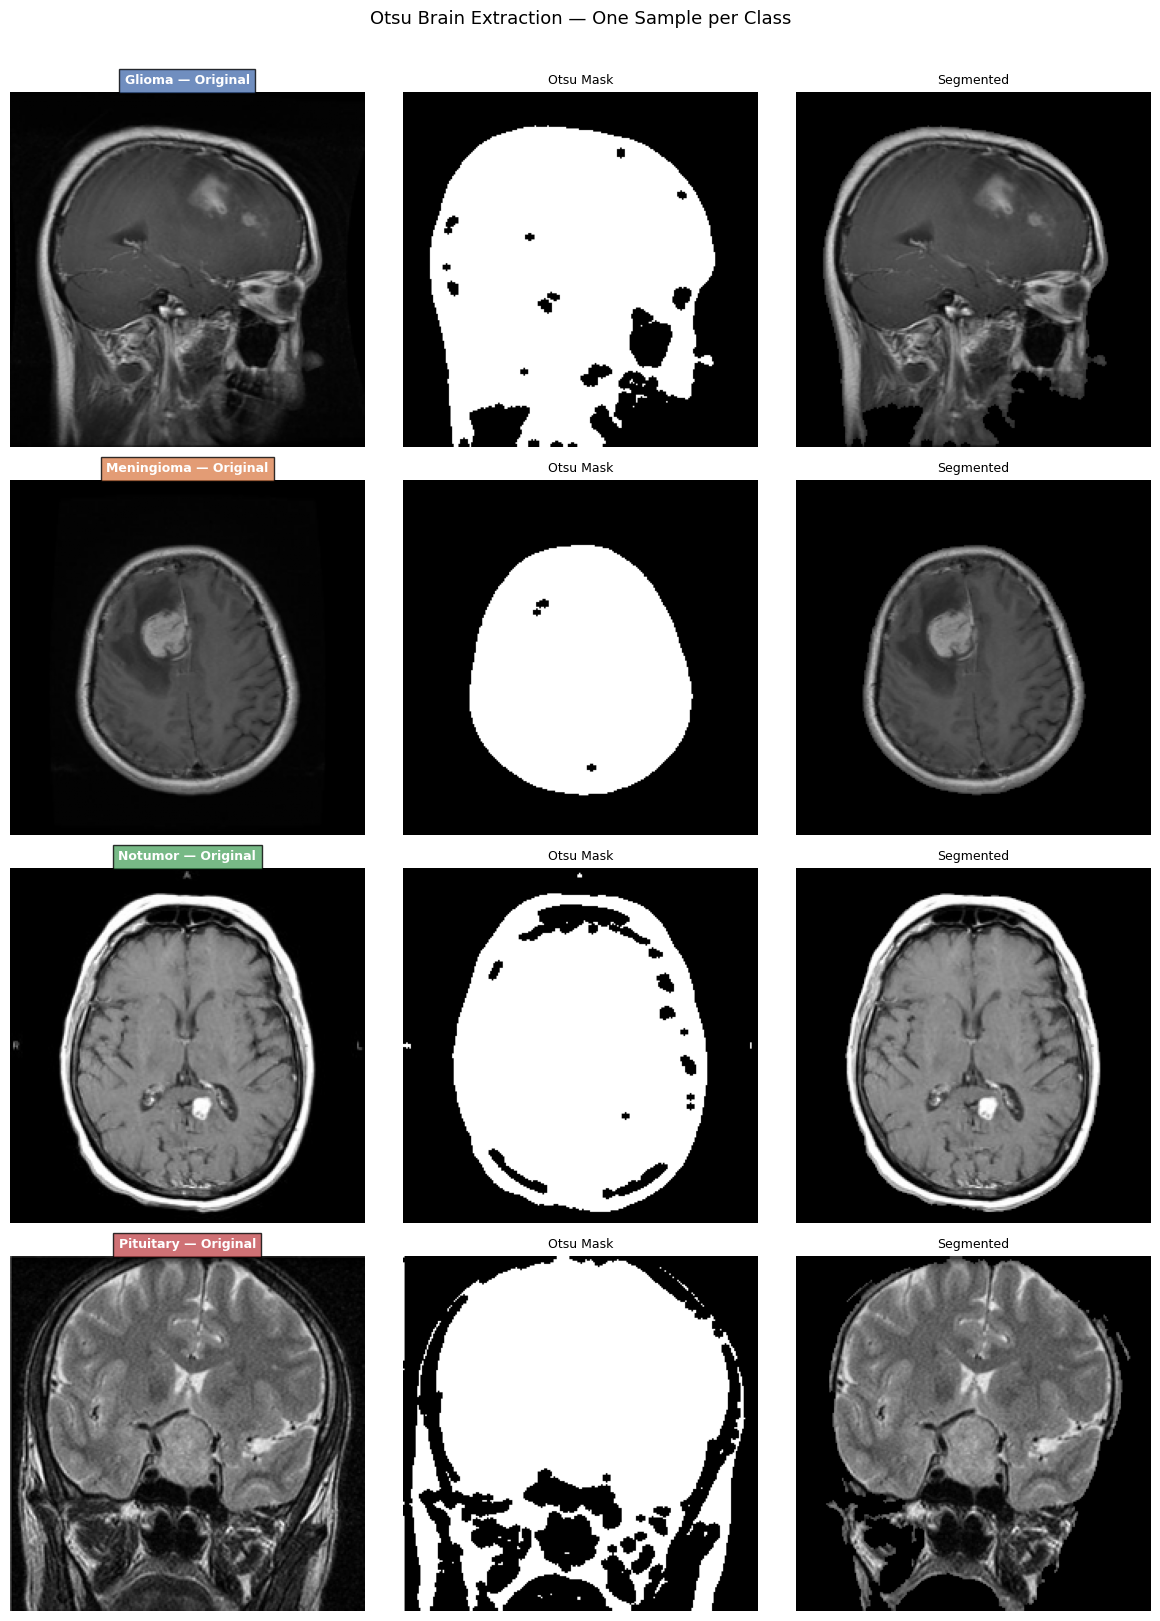

In [ ]:
colours = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']

fig, axes = plt.subplots(4, 3, figsize=(12, 16))

for row, (cls, colour) in enumerate(zip(CLASSES, colours)):
    img_path = next((TRAIN_DIR / cls).glob('*.jpg'))
    original = np.array(Image.open(img_path).convert('RGB').resize(IMG_SIZE)) / 255.0

    gray = cv2.cvtColor((original * 255).astype(np.uint8), cv2.COLOR_RGB2GRAY)
    _, mask = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)

    segmented = otsu_segment(original)

    axes[row, 0].imshow(original, cmap='gray')
    axes[row, 0].set_title(f'{cls.capitalize()} — Original', fontsize=9,
                            color='white', fontweight='bold',
                            bbox=dict(facecolor=colour, alpha=0.8))
    axes[row, 0].axis('off')

    axes[row, 1].imshow(mask, cmap='gray')
    axes[row, 1].set_title('Otsu Mask', fontsize=9)
    axes[row, 1].axis('off')

    axes[row, 2].imshow(segmented, cmap='gray')
    axes[row, 2].set_title('Segmented', fontsize=9)
    axes[row, 2].axis('off')

plt.suptitle('Otsu Brain Extraction — One Sample per Class', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

## 4. Segmented Data Generators

In [ ]:
def otsu_for_generator(img_array):
    return otsu_segment(img_array / 255.0)

seg_train_datagen = ImageDataGenerator(
    preprocessing_function=otsu_for_generator,
    rescale=None,
    rotation_range=15,
    zoom_range=0.10,
    horizontal_flip=True,
    width_shift_range=0.10,
    height_shift_range=0.10,
)
seg_val_test_datagen = ImageDataGenerator(preprocessing_function=otsu_segment)

seg_train_gen = seg_train_datagen.flow_from_dataframe(
    train_df, x_col='filepath', y_col='label',
    target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', shuffle=True, seed=42)

seg_val_gen = seg_val_test_datagen.flow_from_dataframe(
    val_df, x_col='filepath', y_col='label',
    target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', shuffle=False)

seg_test_gen = seg_val_test_datagen.flow_from_dataframe(
    test_df, x_col='filepath', y_col='label',
    target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', shuffle=False)

CLASS_NAMES = list(seg_train_gen.class_indices.keys())
print('Class mapping:', seg_train_gen.class_indices)

Found 3920 validated image filenames belonging to 4 classes.
Found 840 validated image filenames belonging to 4 classes.
Found 840 validated image filenames belonging to 4 classes.
Class mapping: {'glioma': 0, 'meningioma': 1, 'notumor': 2, 'pituitary': 3}


## 5. Pipeline Verification

Batch shape: (32, 224, 224, 3)  |  Label shape: (32, 4)
Pixel range: [0.000, 1.000]


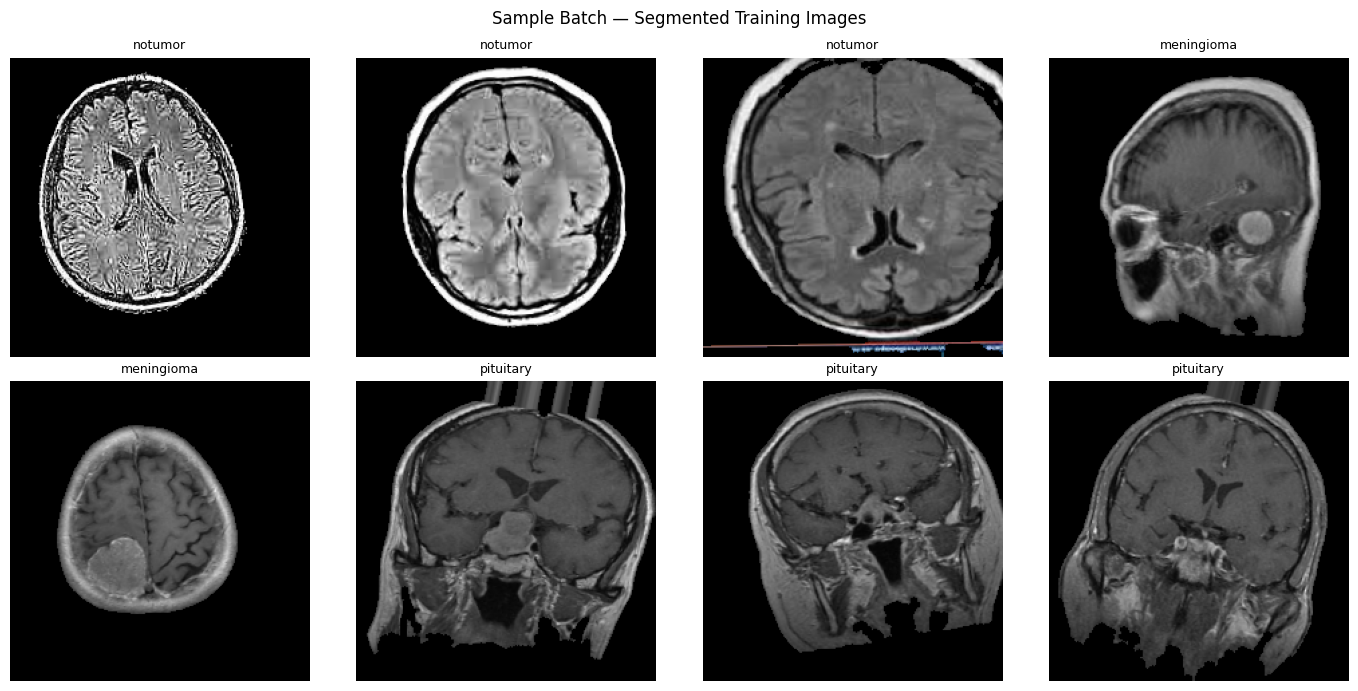

Segmented pipeline verified.


In [ ]:
batch_x, batch_y = next(seg_train_gen)
print(f'Batch shape: {batch_x.shape}  |  Label shape: {batch_y.shape}')
print(f'Pixel range: [{batch_x.min():.3f}, {batch_x.max():.3f}]')

fig, axes = plt.subplots(2, 4, figsize=(14, 7))
for ax, img, lbl in zip(axes.flat, batch_x[:8], batch_y[:8]):
    ax.imshow(img)
    ax.set_title(CLASS_NAMES[np.argmax(lbl)], fontsize=9)
    ax.axis('off')
plt.suptitle('Sample Batch — Segmented Training Images', fontsize=12)
plt.tight_layout()
plt.show()
print('Segmented pipeline verified.')